# Advanced phase maps

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba, LinearSegmentedColormap, ListedColormap
from IPython.display import display
from ipywidgets import Dropdown, interactive, Layout
from pathlib import Path

plt.rcParams['figure.dpi'] = 150

In [2]:
folder_data = './data/'
max_nccs = np.load(folder_data + 'max_nccs.npy')
phase_maps = np.load(folder_data + 'phase_maps.npy')

In [3]:
def get_overlap_names(names):
    names_overlap = names.copy()
    
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            names_overlap.append(names[i]+'+'+names[j])
                
    return names_overlap


def get_overlap_colors(names, names_overlap, colors_rgba, t=0.5):    
    colors_overlap = np.zeros((len(names_overlap), 4))
    colors_overlap[:len(names)] = colors_rgba
    
    for i in range(len(names), len(names_overlap)): 
        name_a, name_b = str.split(names_overlap[i], '+')
        index_a = int(np.where([name == name_a for name in names_overlap])[0][0])
        index_b = int(np.where([name == name_b for name in names_overlap])[0][0])
        color_a, color_b = colors_rgba[index_a], colors_rgba[index_b]
        colors_overlap[i] = np.sqrt((1 - t) * np.square(color_a) + t * np.square(color_b))
    
    return colors_overlap


In [4]:
names = [r'$\theta^{\prime}_{001}$', r'$\theta^{\prime}_{100-1}$', r'$\theta^{\prime}_{100-2}$', r'T$_{1-1}$', r'T$_{1-2}$']
colors = ('cornflowerblue', 'orange', 'salmon', 'seagreen', 'darkseagreen')
cmap = ListedColormap(np.insert(colors, 0, 'linen', axis=0))

names_overlap = get_overlap_names(names)
colors_rgba = [to_rgba(c) for c in colors]
colors_rgba_overlap = get_overlap_colors(names, names_overlap, colors_rgba)
colors_rgba_overlap = np.insert(colors_rgba_overlap, 0, to_rgba('linen'), axis=0)
cmap_overlap = LinearSegmentedColormap.from_list('gt_cmap', colors_rgba_overlap, N=len(colors_rgba_overlap))

names_add = [r'$\theta^{\prime}_{100-1-2}$', r'$\theta^{\prime}_{100-1-3}$', r'$\theta^{\prime}_{100-2-2}$', r'$\theta^{\prime}_{100-2-3}$', 'x']
names_all = names_overlap + names_add
names = np.insert(names, 0, 'Al', axis=0)
names_overlap = np.insert(names_overlap, 0, 'Al', axis=0)
names_all = np.insert(names_all, 0, 'Al', axis=0)

colors_add = ['chocolate', 'xkcd:dark orange', 'indianred', 'xkcd:dull red', 'deeppink']
colors_add_rgbs = [to_rgba(color) for color in colors_add]
colors_all_rgba = colors_rgba_overlap.copy()
colors_all_rgba = np.append(colors_all_rgba, colors_add_rgbs, axis=0)
cmap_all = LinearSegmentedColormap.from_list('gt_cmap', colors_all_rgba, N=len(colors_all_rgba))

namess = [names, names_overlap, names_all, names_all]
cmaps = [cmap, cmap_overlap, cmap_all, cmap_all]

Dropdown(description='Templates:', index=2, layout=Layout(width='300px'), options=('NMF', 'NMF + overlap', 'NM…

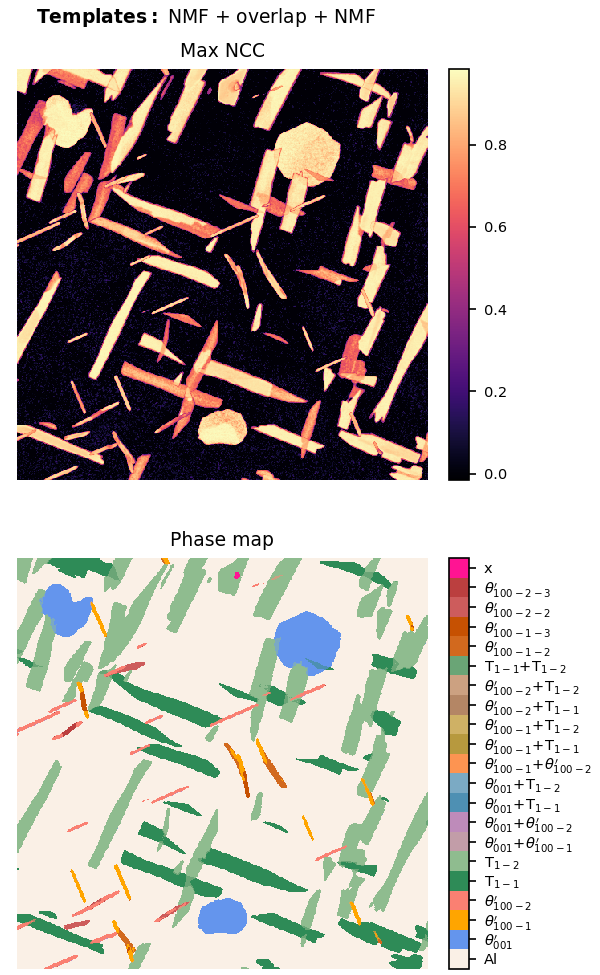

In [5]:
# | label: app:advanced_phase_map_widget
fig = plt.figure(layout='constrained', figsize=(4, 6.5))

ax, ax1 = fig.subplots(2, 1, gridspec_kw={'hspace': 0.1, 'left': 0.01, 'right': 0.85, 'bottom': 0.01, 'top': 0.92})
ax.axis('off')
n_ax = ax.imshow(max_nccs[2], cmap='magma', interpolation='none')
ax.set_title('Max NCC', fontsize=9)
n_cbar = fig.colorbar(n_ax)
n_cbar.ax.tick_params(labelsize=7)

i = 2
ax1.axis('off')
p_ax = ax1.imshow(phase_maps[i], cmap=cmaps[i], interpolation='none')
ax1.set_title('Phase map', fontsize=9)
cbar = fig.colorbar(p_ax)
yticks = np.linspace(*cbar.ax.get_ylim(), cmap_all.N+1)[:-1]
yticks += (yticks[1] - yticks[0]) / 2
cbar.set_ticks(yticks, labels=namess[i], fontsize=7)
plt.axis('off')

fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True
fig.canvas.toolbar_position = 'top'

templates = ['NMF', 'NMF + overlap', 'NMF + overlap + NMF', 'NMF + overlap + clustering']
fig.suptitle(r'$\bf{Templates:}$ ' + templates[i], fontsize=9, x=0.06, ha='left')

def update_plot(change):
    if change['new'] == 'NMF':
        i = 0
    elif change['new'] == 'NMF + overlap':
        i = 1
    elif change['new'] == 'NMF + overlap + NMF':
        i = 2
    elif change['new'] == 'NMF + overlap + clustering':
        i = 3   
    fig.suptitle(r'$\bf{Templates:}$ ' + templates[i], fontsize=9, x=0.06, ha='left')
    n_ax.set_data(max_nccs[i])
    n_ax.set_clim([np.min(max_nccs[i]), np.max(max_nccs[i])])
    n_cbar.update_normal(n_ax)
        
    p_ax.set_data(phase_maps[i])
    p_ax.set_cmap(cmaps[i])
    p_ax.set_clim([-1, np.max(phase_maps[i])])
    cbar.update_normal(p_ax)
    yticks = np.linspace(*cbar.ax.get_ylim(), cmaps[i].N+1)[:-1]
    yticks += (yticks[1] - yticks[0]) / 2
    cbar.set_ticks(yticks, labels=namess[i])
    fig.canvas.draw_idle()
    return None

template_widget = Dropdown(options=templates, index=i, description='Templates:', layout=Layout(width='300px'), disabled=False)
template_widget.observe(update_plot, names='value')
display(template_widget)